In [1]:
import time, os, copy
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import ResNet50_Weights
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda:1")
model_path = "./weights/best_model.pth"
model = models.resnet50(weights=ResNet50_Weights.DEFAULT)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_features, 11)
)

model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [3]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
dummy = torch.randn((1, 3, 256, 256))
outputs = model(dummy)
torch.max(outputs, 1), outputs

(torch.return_types.max(
 values=tensor([-3.4761], grad_fn=<MaxBackward0>),
 indices=tensor([3])),
 tensor([[-3.7159, -4.4757, -5.9694, -3.4761, -4.7168, -6.4897, -6.1420, -6.1529,
          -5.7108, -5.6096, -5.4357]], grad_fn=<AddmmBackward0>))

In [5]:
feature_maps = {}

def get_hook(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach().cpu()
    return hook

# 注册到前面几层
model.conv1.register_forward_hook(get_hook('conv1'))
model.layer1.register_forward_hook(get_hook('layer1'))
model.layer2.register_forward_hook(get_hook('layer2'))
model.layer3.register_forward_hook(get_hook('layer3'))

In [6]:
label_dict = {
    0:'real_ffhq', 1:'ProGAN', 2:'MMDGAN', 3:'ProGAN', 4:'StyleGAN',
    5:'VanillaVAE', 6:'BetaVAE', 7:'Diffusion_ADM', 8:'DDPM', 9:'SD_v15',
    10:'SD_v21' 
}

In [13]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

img = Image.open('./test_images/test1.jpg').convert('RGB')
img = transform(img).unsqueeze(0)

In [16]:
with torch.no_grad():
    model.eval()
    _ = model(img)

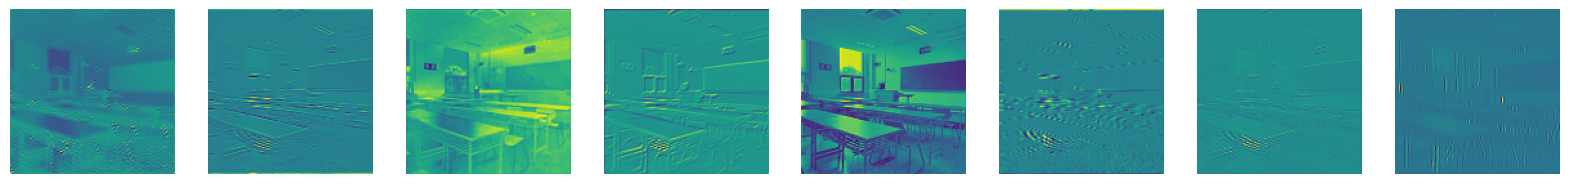

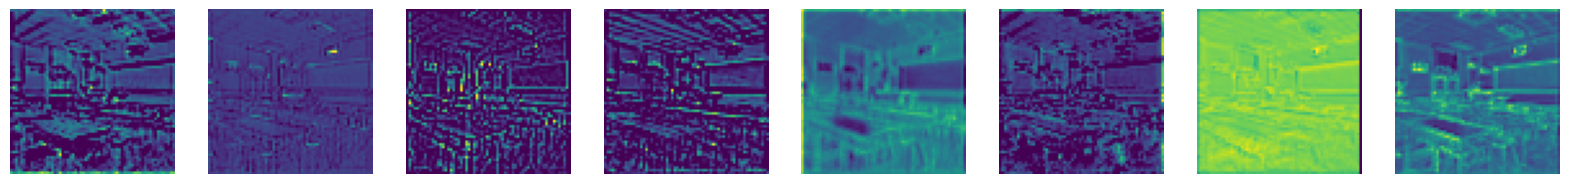

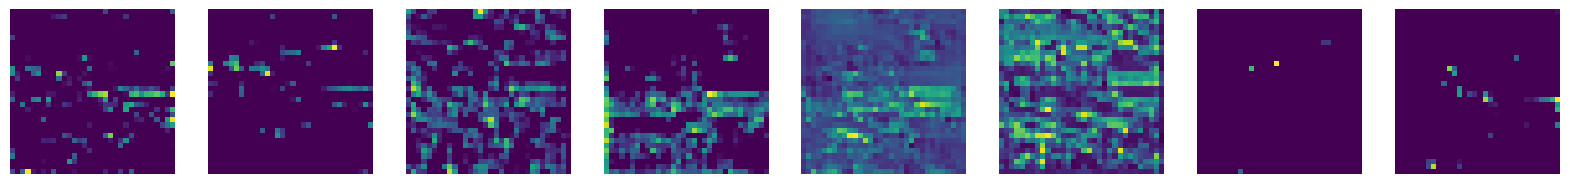

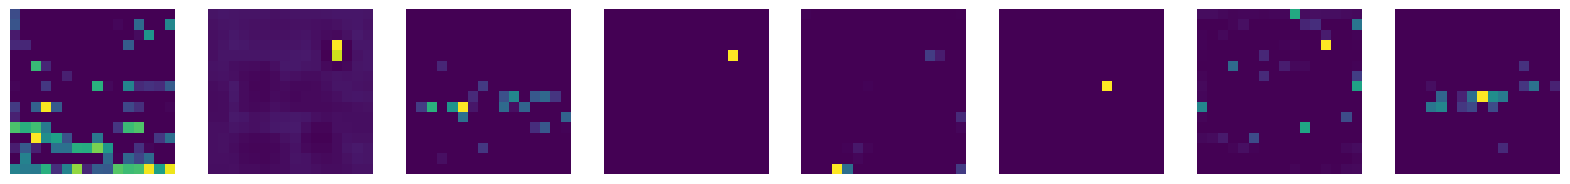

In [ ]:
import matplotlib.pyplot as plt

def visualize_feature_map(feat, num_channels=8):
    # feat: shape (1, C, H, W)
    feat = feat.squeeze(0)[:num_channels]  # 取前 num_channels 个通道 ,例如在经过Conv1后，1张图片的形状就会变成(1, 64, 128, 128)
    fig, axs = plt.subplots(1, num_channels, figsize=(20,10))
    for i in range(num_channels):
        axs[i].imshow(feat[i], cmap='viridis')
        axs[i].axis('off')
    plt.show()

# 可视化 conv1 层
visualize_feature_map(feature_maps['conv1'])
visualize_feature_map(feature_maps['layer1'])
visualize_feature_map(feature_maps['layer2'])
visualize_feature_map(feature_maps['layer3'])

In [15]:
torch.max(outputs, 1), outputs

(torch.return_types.max(
 values=tensor([-3.4761], grad_fn=<MaxBackward0>),
 indices=tensor([3])),
 tensor([[-3.7159, -4.4757, -5.9694, -3.4761, -4.7168, -6.4897, -6.1420, -6.1529,
          -5.7108, -5.6096, -5.4357]], grad_fn=<AddmmBackward0>))

In [27]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []

        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        handle1 = self.target_layer.register_forward_hook(forward_hook)
        handle2 = self.target_layer.register_backward_hook(backward_hook)
        self.hook_handles.extend([handle1, handle2])

    def remove_hooks(self):
        for handle in self.hook_handles:
            handle.remove()

    def __call__(self, input_tensor, class_idx=None):
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        # 反向传播目标类别
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()

        # 计算 Grad-CAM
        pooled_grad = torch.mean(self.gradients, dim=[0, 2, 3])  # [C]
        weighted_activations = self.activations[0] * pooled_grad[:, None, None]
        cam = weighted_activations.sum(dim=0)  # [H, W]
        cam = F.relu(cam)

        # 归一化 & 转 numpy
        cam = cam - cam.min()
        cam = cam / cam.max()
        cam = cam.cpu().numpy()

        return cam

In [ ]:
def show_cam_on_image(img, mask, alpha=0.5):
    heatmap = cv2.applyColorMap(np.uint8(255 * mask), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255
    img = np.array(img.resize((mask.shape[1], mask.shape[0]))) / 255
    cam_img = heatmap * alpha + img * (1 - alpha)
    cam_img = cam_img / cam_img.max()
    plt.imshow(cam_img)
    plt.axis('off')
    plt.show()